# Module 2 · Class 5 · Level 3
# Descriptive Statistics and Correlation — Exercises Only

Minimal theory. Complete the TODO cells.

Topics: mean, variance, standard deviation, mean vs median, correlation, heatmap, scatter plot, interpretation.

## 0. Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("Setup complete.")

Setup complete.


## 0.1 Dataset loading

Use **one** of the three loading options below.

**Option 1 — Preferred:** use `superstore_cleaned.csv` or `SampleSuperstore.csv` already uploaded to Colab.  
**Option 2 — Manual upload:** upload the CSV from your computer.  
**Option 3 — External source:** download the Superstore dataset from Kaggle, with a public CSV fallback.

Set `LOAD_MODE` to one of: `"preferred"`, `"manual_upload"`, `"external_source"`.

In [2]:
LOAD_MODE = "preferred"  # "preferred", "manual_upload", or "external_source"

PREFERRED_PATHS = [
    "superstore_cleaned.csv",
    "SampleSuperstore.csv",
    "Sample - Superstore.csv",
    "/content/superstore_cleaned.csv",
    "/content/SampleSuperstore.csv",
    "/content/Sample - Superstore.csv",
]

KAGGLE_DATASET = "vivek468/superstore-dataset-final"
PUBLIC_FALLBACK_URL = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"


def read_csv_safely(path_or_url):
    """Try common encodings used by Superstore CSV files."""
    last_error = None
    for enc in ["utf-8", "latin-1", "ISO-8859-1"]:
        try:
            return pd.read_csv(path_or_url, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def find_csv_file(folder):
    csvs = glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True)
    if not csvs:
        raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")
    return csvs[0]


def load_superstore(load_mode=LOAD_MODE):
    if load_mode == "preferred":
        for path in PREFERRED_PATHS:
            if os.path.exists(path):
                print(f"Loading preferred local file: {path}")
                return read_csv_safely(path)
        raise FileNotFoundError(
            "Preferred file not found. Upload superstore_cleaned.csv / SampleSuperstore.csv, "
            "or set LOAD_MODE to 'manual_upload' or 'external_source'."
        )

    if load_mode == "manual_upload":
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No file uploaded.")
        filename = list(uploaded.keys())[0]
        print(f"Loading uploaded file: {filename}")
        return read_csv_safely(filename)

    if load_mode == "external_source":
        try:
            try:
                import kagglehub
            except ImportError:
                print("Installing kagglehub...")
                get_ipython().run_line_magic("pip", "-q install kagglehub")
                import kagglehub
            dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
            csv_path = find_csv_file(dataset_path)
            print(f"Loading Kaggle dataset file: {csv_path}")
            return read_csv_safely(csv_path)
        except Exception as e:
            print(f"Kaggle loading failed: {e}")
            print("Trying public CSV fallback...")
            return read_csv_safely(PUBLIC_FALLBACK_URL)

    raise ValueError("LOAD_MODE must be 'preferred', 'manual_upload', or 'external_source'.")


def normalize_column_name(name):
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")


def find_column(df, possible_names):
    lookup = {normalize_column_name(c): c for c in df.columns}
    for name in possible_names:
        key = normalize_column_name(name)
        if key in lookup:
            return lookup[key]
    # fallback: substring match
    for c in df.columns:
        c_norm = normalize_column_name(c)
        if any(normalize_column_name(name) in c_norm for name in possible_names):
            return c
    raise KeyError(f"Could not find any of these columns: {possible_names}. Available columns: {list(df.columns)}")


df = load_superstore()

# Standard column references used below.
SALES_COL = find_column(df, ["Sales"])
PROFIT_COL = find_column(df, ["Profit"])
DISCOUNT_COL = find_column(df, ["Discount"])
QUANTITY_COL = find_column(df, ["Quantity"])

print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print("Core columns:", SALES_COL, PROFIT_COL, DISCOUNT_COL, QUANTITY_COL)
df.head()

Loading preferred local file: superstore_cleaned.csv
Loaded dataset: 9994 rows, 21 columns
Core columns: Sales Profit Discount Quantity


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Exercise 1 — Create a sample

In [3]:
# TODO: sample 10 values from the Sales column.
sample = df.sample(10)
sample

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4406,4407,CA-2016-100041,2016-11-20,2016-11-25,Standard Class,BF-10975,Barbara Fisher,Corporate,United States,Columbus,...,47201,Central,OFF-PA-10001622,Office Supplies,Paper,"Ampad Poly Cover Wirebound Steno Book, 6"" x 9""...",9.080,2,0.0,4.0860
8192,8193,CA-2015-141327,2015-11-30,2015-12-03,First Class,LR-16915,Lena Radford,Consumer,United States,Durham,...,27707,South,OFF-BI-10000546,Office Supplies,Binders,Avery Durable Binders,6.048,7,0.7,-4.2336
8913,8914,CA-2017-102610,2017-11-04,2017-11-08,Standard Class,CA-12265,Christina Anderson,Consumer,United States,Chattanooga,...,37421,South,OFF-LA-10002195,Office Supplies,Labels,Avery 481,4.928,2,0.2,1.7248
7528,7529,US-2017-106145,2017-09-26,2017-09-26,Same Day,RA-19885,Ruben Ausman,Corporate,United States,San Francisco,...,94109,West,OFF-PA-10002245,Office Supplies,Paper,Xerox 1895,35.880,6,0.0,16.1460
913,914,CA-2017-102519,2017-11-27,2017-11-29,First Class,BM-11650,Brian Moss,Corporate,United States,Milwaukee,...,53209,Central,FUR-FU-10004091,Furniture,Furnishings,"Howard Miller 13"" Diameter Goldtone Round Wall...",46.940,1,0.0,19.2454
8620,8621,US-2017-119319,2017-11-06,2017-11-09,Second Class,LC-17050,Liz Carlisle,Consumer,United States,Dallas,...,75217,Central,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",30.560,5,0.6,-19.8640
3495,3496,CA-2017-142034,2017-09-24,2017-09-28,Standard Class,KB-16240,Karen Bern,Corporate,United States,Saint Cloud,...,56301,Central,FUR-CH-10000665,Furniture,Chairs,"Global Airflow Leather Mesh Back Chair, Black",603.920,4,0.0,181.1760
540,541,CA-2014-140795,2014-02-01,2014-02-03,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,...,54302,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.900,6,0.0,206.3160
1693,1694,US-2016-158708,2016-06-26,2016-06-29,Second Class,AB-10255,Alejandro Ballentine,Home Office,United States,Plano,...,75023,Central,TEC-AC-10003133,Technology,Accessories,Memorex Mini Travel Drive 4 GB USB 2.0 Flash D...,13.616,2,0.2,3.5742
7077,7078,CA-2016-106950,2016-09-02,2016-09-06,Standard Class,JE-15715,Joe Elijah,Consumer,United States,Charlotte,...,28205,South,OFF-BI-10000014,Office Supplies,Binders,Heavy-Duty E-Z-D Binders,22.911,7,0.7,-17.5651


## Exercise 2 — Manual mean

In [4]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 4406 to 7077
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10 non-null     int64  
 1   Order ID       10 non-null     object 
 2   Order Date     10 non-null     object 
 3   Ship Date      10 non-null     object 
 4   Ship Mode      10 non-null     object 
 5   Customer ID    10 non-null     object 
 6   Customer Name  10 non-null     object 
 7   Segment        10 non-null     object 
 8   Country        10 non-null     object 
 9   City           10 non-null     object 
 10  State          10 non-null     object 
 11  Postal Code    10 non-null     int64  
 12  Region         10 non-null     object 
 13  Product ID     10 non-null     object 
 14  Category       10 non-null     object 
 15  Sub-Category   10 non-null     object 
 16  Product Name   10 non-null     object 
 17  Sales          10 non-null     float64
 18  Quantity    

In [5]:
sample.sum()

,0
Row ID,51387
Order ID,CA-2016-100041CA-2015-141327CA-2017-102610US-2...
Order Date,2016-11-202015-11-302017-11-042017-09-262017-1...
Ship Date,2016-11-252015-12-032017-11-082017-09-262017-1...
Ship Mode,Standard ClassFirst ClassStandard ClassSame Da...
Customer ID,BF-10975LR-16915CA-12265RA-19885BM-11650LC-170...
Customer Name,Barbara FisherLena RadfordChristina AndersonRu...
Segment,CorporateConsumerConsumerCorporateCorporateCon...
Country,United StatesUnited StatesUnited StatesUnited ...
City,ColumbusDurhamChattanoogaSan FranciscoMilwauke...


In [6]:
# TODO: calculate the mean manually.
manual_mean = sample['Quantity'].sum() / len(sample[sample['Quantity'] > 0])

print("Manual mean:", manual_mean)
print("NumPy mean:", np.mean(sample['Quantity']))


Manual mean: 4.2
NumPy mean: 4.2


In [7]:
manual_mean.round(1)

np.float64(4.2)

In [8]:
len(df[df['Quantity'] > 0])

9994

## Exercise 3 — Manual variance

In [9]:
# TODO: calculate squared differences and variance manually.
squared_diffs = (sample['Quantity'] - manual_mean) ** 2
squared_diffs

avg = np.mean(sample['Quantity'])
avg_col = sample['Quantity'] - avg
avg_col = avg_col ** 2
res = avg_col.sum() / len(sample['Quantity'])
manual_variance = res

print("Manual variance:", manual_variance)
print("NumPy variance:", np.var(sample['Quantity']))

Manual variance: 4.76
NumPy variance: 4.76


In [10]:
np.var(sample['Quantity'])

4.76

In [11]:
avg = np.mean(sample['Quantity'])
avg_col = sample['Quantity'] - avg
avg_col.sum()


np.float64(-1.7763568394002505e-15)

In [12]:
avg = np.mean(sample['Quantity'])
avg_col = sample['Quantity'] - avg
avg_col = avg_col ** 2
res = avg_col.sum() / len(sample['Quantity'])
manual_variance = res

In [13]:
len(sample['Quantity'])

10

## Exercise 4 — Manual standard deviation

In [14]:
# TODO: calculate standard deviation manually.
avg = np.mean(sample['Quantity'])
avg_col = sample['Quantity'] - avg
avg_col = avg_col ** 2
res = avg_col.sum() / len(sample['Quantity'])
manual_variance = res
manual_std = manual_variance * 0.5

print("Manual std:", manual_std)
print("NumPy std:", np.std(sample['Quantity']))

Manual std: 2.38
NumPy std: 2.181742422927143


## Exercise 5 — Mean vs median

In [15]:
# TODO: compare mean and median on the full Sales column.
sales = sample['Sales']
mean_sales = sales.sum() / len(sales)

median_sales = sales.iloc[int(len(sales)/2)]

print("Mean:", mean_sales)
print("Median:", median_sales)

Mean: 124.27829999999999
Median: 30.56


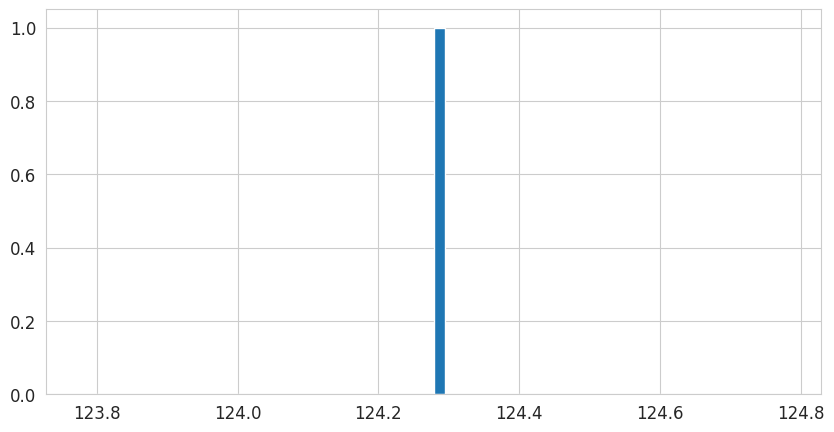

In [16]:
# TODO: plot a histogram and mark mean/median.
plt.figure(figsize=(10, 5))
plt.hist(mean_sales, bins = 60)
plt.show()



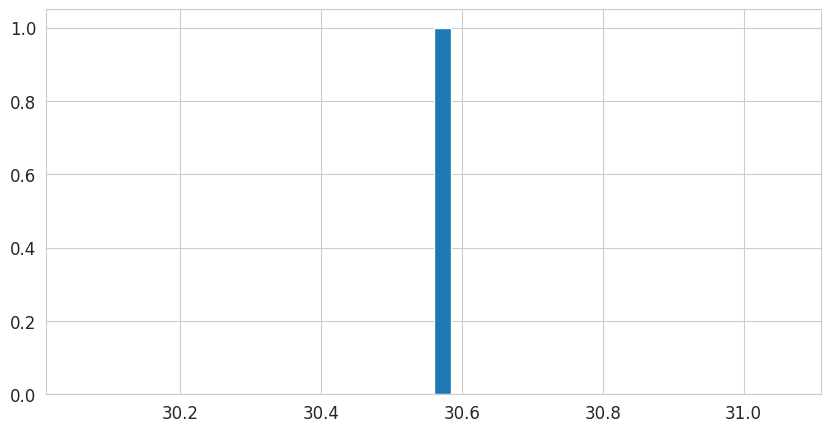

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(median_sales, bins = 40)
plt.show()

**Write:** Is the distribution skewed? Which value better represents a typical order?

...

## Exercise 6 — Correlation

In [18]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 4406 to 7077
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10 non-null     int64  
 1   Order ID       10 non-null     object 
 2   Order Date     10 non-null     object 
 3   Ship Date      10 non-null     object 
 4   Ship Mode      10 non-null     object 
 5   Customer ID    10 non-null     object 
 6   Customer Name  10 non-null     object 
 7   Segment        10 non-null     object 
 8   Country        10 non-null     object 
 9   City           10 non-null     object 
 10  State          10 non-null     object 
 11  Postal Code    10 non-null     int64  
 12  Region         10 non-null     object 
 13  Product ID     10 non-null     object 
 14  Category       10 non-null     object 
 15  Sub-Category   10 non-null     object 
 16  Product Name   10 non-null     object 
 17  Sales          10 non-null     float64
 18  Quantity    

In [19]:
# TODO: calculate correlations between Sales, Profit, and Discount.
corr_sales_profit = sample['Sales'].corr(sample['Profit'])
corr_sales_discount = sample['Sales'].corr(sample['Discount'])
corr_discount_profit = sample['Discount'].corr(sample['Profit'])

print(corr_sales_profit)
print(corr_sales_discount)
print(corr_discount_profit)

0.9663419266876548
-0.4222171401247229
-0.5260317095333447


In [20]:
# TODO: create correlation matrix.
corr_matrix = np.array([corr_sales_profit, corr_sales_discount, corr_discount_profit])
corr_matrix

array([ 0.96634193, -0.42221714, -0.52603171])

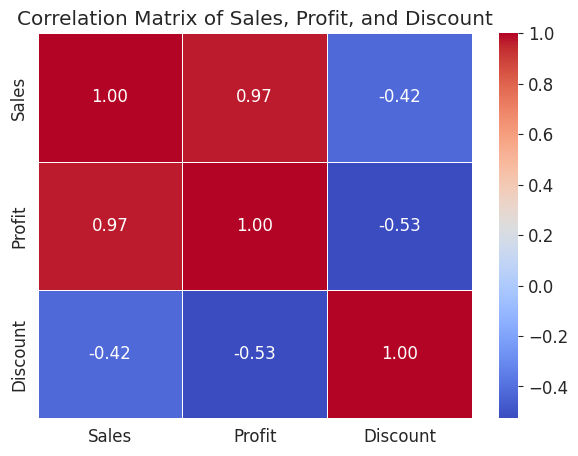

In [24]:
# TODO: draw heatmap.
plt.figure(figsize=(7, 5))

# Create a DataFrame with the relevant columns for correlation
correlation_df = sample[[SALES_COL, PROFIT_COL, DISCOUNT_COL]]
corr_matrix = correlation_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Sales, Profit, and Discount')

plt.show()

In [25]:
corr_matrix

,Sales,Profit,Discount
Sales,1.000000,0.966342,-0.422217
Profit,0.966342,1.000000,-0.526032
Discount,-0.422217,-0.526032,1.000000


## Exercise 7 — Scatter plot

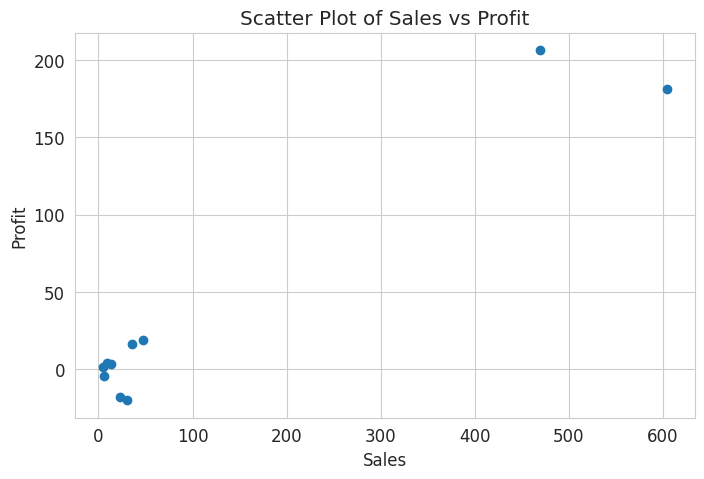

In [30]:
# TODO: scatter plot of Sales vs Profit.
plt.figure(figsize=(8, 5))
cs = sample[[SALES_COL, PROFIT_COL]]

plt.scatter(cs[SALES_COL], cs[PROFIT_COL])
plt.xlabel(SALES_COL)
plt.ylabel(PROFIT_COL)
plt.title(f'Scatter Plot of {SALES_COL} vs {PROFIT_COL}')

plt.show()

In [27]:
sample[[SALES_COL, PROFIT_COL]].corr()

,Sales,Profit
Sales,1.000000,0.966342
Profit,0.966342,1.000000


## Final answers

1. What does mean tell you?
2. What does standard deviation tell you?
3. Which pair has the strongest correlation?
4. What does negative correlation mean?
5. Why is correlation not causation?

...